# Estimativa de $t_c$ e colapso de escala — versão refinada

Mudanças em relação à versão original:

1. `estimate_tc_by_max_slope` usa **Savitzky–Golay** com janela adaptativa em $N$ e recorte de borda.
2. Novo `fit_tc_with_offset`: ajuste não-linear $t_c(N)=t_\infty + a\,N^{-\theta}$.
3. Separação clara entre `theta_tc` (scaling de $t_c$) e `theta_collapse` (expoente do colapso).
4. `collapse_score_physical` com `pmin/pmax` consistentes e descarte opcional da pior curva.
5. Substituído `plt.cm.get_cmap` (depreciado) por `plt.get_cmap`.
6. Novo `fit_power_law_times_log`: ajuste com correção logarítmica $t_c(N)\sim N^{\theta}\log N$.
7. Comparação automática entre $N^{\theta}$ e $N^{\theta}\log N$ usando $R^2$ (impressa no diagnóstico).

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

mpl.rcParams["text.usetex"] = True

## Leitura e limpeza

In [2]:
def load_csv_attack(N, C, mode="random"):
    fname = f"./data_random_medias_random/{mode}_{N}_{C}.csv"
    if not os.path.exists(fname):
        print(f"[AVISO] Arquivo não encontrado: {fname}")
        return pd.DataFrame()
    df = pd.read_csv(fname, sep=",", header=0)
    return df.drop(columns=["node1", "node2"], errors="ignore")


def clean_tp(df):
    if df.empty or ("t" not in df.columns) or ("p" not in df.columns):
        return np.array([]), np.array([])

    t = np.asarray(df["t"], float)
    p = np.asarray(df["p"], float)

    mask = np.isfinite(t) & np.isfinite(p) & (t > 0)
    t, p = t[mask], p[mask]

    if len(t) == 0:
        return t, p

    idx = np.argsort(t)
    return t[idx], p[idx]

## Estimadores de $t_c(N)$ e $t_{\max}(N)$

Definição: $t_c(N) = \arg\max_t \dfrac{dp}{d\ln t}$, com a derivada suavizada por Savitzky–Golay (preserva a posição do pico melhor que média móvel).

In [3]:
def _sg_window(n_points, frac=0.05, wmin=7, wmax=51):
    w = int(max(wmin, min(wmax, frac * n_points)))
    if w % 2 == 0:
        w += 1
    return w


def estimate_tc_by_max_slope(df, edge_frac=0.05):
    t, p = clean_tp(df)
    n = len(t)
    if n < 25:
        return np.nan

    logt = np.log(t)
    dp_dlogt = np.gradient(p, logt)

    window = _sg_window(n, frac=0.05, wmin=7, wmax=51)
    if window < n:
        try:
            dp_dlogt = savgol_filter(dp_dlogt, window, polyorder=3)
        except ValueError:
            pass

    k = max(2, int(edge_frac * n))
    interior = slice(k, n - k)

    i_local = int(np.argmax(dp_dlogt[interior]))
    return float(t[interior][i_local])


def estimate_tmax(df):
    t, _ = clean_tp(df)
    if len(t) == 0:
        return np.nan
    return float(np.max(t))

## Ajustes: lei de potência log-log, com correção log e com offset

- Log-log puro: $y = A\,N^\alpha$.
- Correção logarítmica: $t_c(N) = A\,N^\theta\log N$.
- Com offset: $t_c(N) = t_\infty + a\,N^{-\theta}$. Se $t_\infty$ for compatível com zero, o ajuste log-log puro é justificado.

In [ ]:
def fit_power_law(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]

    if len(x) < 2:
        return np.nan, np.nan, np.nan

    logx, logy = np.log(x), np.log(y)
    alpha, intercept = np.polyfit(logx, logy, 1)
    logy_hat = alpha * logx + intercept

    ss_res = np.sum((logy - logy_hat) ** 2)
    ss_tot = np.sum((logy - np.mean(logy)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return alpha, intercept, r2


def fit_power_law_times_log(x, y, log_power=1.0):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 1.0) & (y > 0)
    x, y = x[mask], y[mask]

    if len(x) < 2:
        return np.nan, np.nan, np.nan

    logx = np.log(x)
    loglogx = np.log(logx)
    logy = np.log(y)

    # Ajuste linear de log(y/log(N)^k) = intercept + theta*log(N)
    y_reduced = logy - log_power * loglogx
    theta, intercept = np.polyfit(logx, y_reduced, 1)
    logy_hat = intercept + theta * logx + log_power * loglogx

    ss_res = np.sum((logy - logy_hat) ** 2)
    ss_tot = np.sum((logy - np.mean(logy)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return theta, intercept, r2


def fit_tc_with_offset(Ns, tcs):
    Ns = np.asarray(Ns, float)
    tcs = np.asarray(tcs, float)
    mask = np.isfinite(Ns) & np.isfinite(tcs) & (Ns > 0)
    Ns, tcs = Ns[mask], tcs[mask]

    if len(Ns) < 4:
        return None

    def model(N, t_inf, a, theta):
        return t_inf + a * N ** (-theta)

    alpha, intercept, _ = fit_power_law(Ns, tcs)
    p0 = [
        float(np.min(tcs)) * 0.5,
        float(np.exp(intercept)) if np.isfinite(intercept) else 1.0,
        float(-alpha) if np.isfinite(alpha) else 0.5,
    ]
    try:
        popt, _ = curve_fit(model, Ns, tcs, p0=p0, maxfev=20000)
        residuals = tcs - model(Ns, *popt)
        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((tcs - np.mean(tcs)) ** 2)
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
        return {"t_inf": popt[0], "a": popt[1], "theta": popt[2], "r2": r2}
    except (RuntimeError, ValueError):
        return None

## Score de colapso e estimativa de $\theta_{\text{collapse}}$

Minimiza a variância vertical das curvas $p$ vs $(t - t_c)\,N^{-\theta}$, ponderada por $|d\bar p/dx|$ para enfatizar a janela crítica. Descarta opcionalmente a curva mais discordante.

In [5]:
def collapse_score_physical(
    dfs, Ns, tcs, theta,
    masks=None, pmin=0.05, pmax=0.9, ngrid=400,
    drop_worst=True,
):
    curves = []
    for i, (df, N, tc) in enumerate(zip(dfs, Ns, tcs)):
        t, p = clean_tp(df)
        if len(t) == 0 or not np.isfinite(tc):
            continue
        m = masks[i] if masks is not None else ((p >= pmin) & (p <= pmax))
        if np.sum(m) < 10:
            continue
        t, p = t[m], p[m]
        x = (t - tc) * (N ** (-theta))
        idx = np.argsort(x)
        curves.append((x[idx], p[idx]))

    if len(curves) < 2:
        return np.inf

    left = max(c[0][0] for c in curves)
    right = min(c[0][-1] for c in curves)
    if not left < right:
        return np.inf

    grid = np.linspace(left, right, ngrid)
    P = np.vstack([np.interp(grid, x, p) for x, p in curves])

    mean_curve = np.mean(P, axis=0)
    dPdx = np.gradient(mean_curve, grid)
    weight = np.abs(dPdx) + 1e-7

    if drop_worst and P.shape[0] >= 4:
        dev = np.average((P - mean_curve) ** 2, axis=1, weights=weight)
        keep = np.ones(P.shape[0], dtype=bool)
        keep[int(np.argmax(dev))] = False
        P = P[keep]
        mean_curve = np.mean(P, axis=0)

    score = np.average(np.var(P, axis=0), weights=weight)
    return float(score)


def estimate_theta_by_collapse(
    dfs, Ns, tcs,
    masks=None, theta_min=0.0, theta_max=6.0,
    coarse_points=300, refine_points=300,
    pmin=0.05, pmax=0.9,
):
    def score(theta):
        return collapse_score_physical(
            dfs, Ns, tcs, theta,
            masks=masks, pmin=pmin, pmax=pmax,
        )

    grid1 = np.linspace(theta_min, theta_max, coarse_points)
    scores1 = np.array([score(th) for th in grid1])
    i1 = int(np.argmin(scores1))
    theta1 = float(grid1[i1])

    step = (theta_max - theta_min) / (coarse_points - 1)
    left = max(theta_min, theta1 - 3 * step)
    right = min(theta_max, theta1 + 3 * step)

    grid2 = np.linspace(left, right, refine_points)
    scores2 = np.array([score(th) for th in grid2])
    return float(grid2[int(np.argmin(scores2))])

## Impressões e diagnósticos

In [ ]:
def print_tcs(Ns, tcs_dict):
    print("\n==============================")
    print("t_c(N) encontrados")
    print("==============================")
    for label, tcs in tcs_dict.items():
        print(f"\n{label}")
        for N, tc in zip(Ns, tcs):
            print(f"N={int(N):5d} | t_c={tc:.6g}")


def print_scalings(Ns, tcs_dict, tmaxs_dict):
    print("\n==============================")
    print("AJUSTE log-log puro: t_c ~ N^theta")
    print("==============================")
    pure_fit = {}
    for label, tcs in tcs_dict.items():
        theta, b, r2 = fit_power_law(Ns, tcs)
        pure_fit[label] = (theta, b, r2)
        if np.isfinite(theta):
            print(f"{label}: t_c ~ N^{theta:.3f} (R² = {r2:.3f})")
        else:
            print(f"{label}: ajuste falhou")

    print("\n==============================")
    print("AJUSTE COM CORREÇÃO LOG: t_c ~ N^theta log(N)")
    print("==============================")
    log_fit = {}
    for label, tcs in tcs_dict.items():
        theta, b, r2 = fit_power_law_times_log(Ns, tcs, log_power=1.0)
        log_fit[label] = (theta, b, r2)
        if np.isfinite(theta):
            print(f"{label}: t_c ~ N^{theta:.3f} log(N) (R² = {r2:.3f})")
        else:
            print(f"{label}: ajuste falhou")

    print("\nComparação (R² maior favorece o modelo):")
    for label in tcs_dict:
        r2_pure = pure_fit[label][2]
        r2_log = log_fit[label][2]
        if np.isfinite(r2_pure) and np.isfinite(r2_log):
            winner = "N^theta log(N)" if r2_log > r2_pure else "N^theta"
            print(f"{label}: R²_puro={r2_pure:.3f}, R²_log={r2_log:.3f} -> favorece {winner}")
        else:
            print(f"{label}: comparação indisponível")

    print("\n==============================")
    print("AJUSTE COM OFFSET: t_c(N) = t_inf + a N^(-theta)")
    print("==============================")
    for label, tcs in tcs_dict.items():
        fit = fit_tc_with_offset(Ns, tcs)
        if fit is None:
            print(f"{label}: ajuste com offset falhou")
        else:
            print(
                f"{label}: t_inf={fit['t_inf']:.4g}, "
                f"a={fit['a']:.4g}, theta={fit['theta']:.3f}, "
                f"R²={fit['r2']:.3f}"
            )

    print("\n==============================")
    print("AJUSTE t_max(N) ~ N^alpha")
    print("==============================")
    for label, tmaxs in tmaxs_dict.items():
        alpha, _, r2 = fit_power_law(Ns, tmaxs)
        if np.isfinite(alpha):
            print(f"{label}: t_max ~ N^{alpha:.3f} (R² = {r2:.3f})")
        else:
            print(f"{label}: ajuste falhou")

## Plots: scaling, razão, diagnóstico e colapso

In [ ]:
def plot_scaling_tc_tmax(Ns, C1_dfs, C2_dfs, C3_dfs, CN_dfs):
    tcs_dict = {
        r"$C=1$": np.array([estimate_tc_by_max_slope(df) for df in C1_dfs]),
        r"$C=2$": np.array([estimate_tc_by_max_slope(df) for df in C2_dfs]),
        r"$C=3$": np.array([estimate_tc_by_max_slope(df) for df in C3_dfs]),
        r"$C=N$": np.array([estimate_tc_by_max_slope(df) for df in CN_dfs]),
    }
    tmaxs_dict = {
        r"$C=1$": np.array([estimate_tmax(df) for df in C1_dfs]),
        r"$C=2$": np.array([estimate_tmax(df) for df in C2_dfs]),
        r"$C=3$": np.array([estimate_tmax(df) for df in C3_dfs]),
        r"$C=N$": np.array([estimate_tmax(df) for df in CN_dfs]),
    }

    markers = {r"$C=1$": "s", r"$C=2$": "o", r"$C=3$": "^", r"$C=N$": "D"}
    colors = {r"$C=1$": "black", r"$C=2$": "purple", r"$C=3$": "red", r"$C=N$": "orange"}

    print_tcs(Ns, tcs_dict)
    print_scalings(Ns, tcs_dict, tmaxs_dict)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    Nfit = np.logspace(np.log10(np.min(Ns)), np.log10(np.max(Ns)), 300)

    for label, tcs in tcs_dict.items():
        theta, b, _ = fit_power_law(Ns, tcs)
        theta_log, b_log, _ = fit_power_law_times_log(Ns, tcs, log_power=1.0)

        ax[0].loglog(Ns, tcs, marker=markers[label], linestyle="None",
                     color=colors[label], label=label)
        if np.isfinite(theta):
            ax[0].loglog(Nfit, np.exp(b) * Nfit ** theta, "--", color=colors[label])
        if np.isfinite(theta_log):
            ax[0].loglog(
                Nfit,
                np.exp(b_log) * Nfit ** theta_log * np.log(Nfit),
                ":",
                color=colors[label],
            )

    ax[0].set_xlabel(r"$N$")
    ax[0].set_ylabel(r"$t_c(N)$")
    ax[0].set_title(r"(e)")
    legend_lines = [
        Line2D([0], [0], color="gray", linestyle="--", label=r"$N^{\theta}$"),
        Line2D([0], [0], color="gray", linestyle=":", label=r"$N^{\theta}\log N$"),
    ]
    handles, labels = ax[0].get_legend_handles_labels()
    ax[0].legend(handles=handles + legend_lines, labels=labels + [l.get_label() for l in legend_lines])

    for label, tmaxs in tmaxs_dict.items():
        alpha, b, _ = fit_power_law(Ns, tmaxs)
        ax[1].loglog(Ns, tmaxs, marker=markers[label], linestyle="None",
                     color=colors[label], label=label)
        if np.isfinite(alpha):
            ax[1].loglog(Nfit, np.exp(b) * Nfit ** alpha, "--", color=colors[label])

    ax[1].set_xlabel(r"$N$")
    ax[1].set_ylabel(r"$t_{\max}(N)$")
    ax[1].set_title(r"(f)")
    ax[1].legend()

    plt.tight_layout()
    plt.savefig("scaling_tc_tmax.png", dpi=300, bbox_inches="tight")
    plt.show()
    return tcs_dict, tmaxs_dict


def plot_tc_diagnostic(Ns, dfs, tcs, title):
    fig, ax = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
    for a, N, df, tc in zip(ax.flat, Ns, dfs, tcs):
        t, p = clean_tp(df)
        a.plot(t, p, lw=2)
        if np.isfinite(tc):
            a.axvline(tc, color="red", linestyle="--", lw=1.5)
        a.set_xscale("log")
        a.set_title(rf"$N={int(N)}$")
        a.set_xlabel(r"$t$")
        a.set_ylabel(r"$p(t,N)$")
        a.tick_params(direction="in", top=True, right=True)
    fig.suptitle(title)
    plt.show()


def plot_collapse_panel(ax, dfs, Ns, tcs, theta, styles, title):
    for df, N, tc, st in zip(dfs, Ns, tcs, styles):
        t, p = clean_tp(df)
        if len(t) == 0 or not np.isfinite(tc):
            continue
        x = (t - tc) * N ** (-theta)
        ax.plot(x, p, **st)
    ax.set_xscale("symlog")
    ax.set_xlabel(r"$(t-t_c)N^{-\theta}$")
    ax.set_ylabel(r"$p$")
    ax.set_title(title)
    ax.tick_params(direction="in", top=True, right=True)


def plot_tc_over_tmax(Ns, tcs_dict, tmaxs_dict):
    print("\n" + "=" * 80)
    print("ESCALA DA RAZÃO t_c / t_max")
    print("=" * 80)

    markers = {r"$C=1$": "s", r"$C=2$": "o", r"$C=3$": "^", r"$C=N$": "D"}
    colors = {r"$C=1$": "black", r"$C=2$": "purple", r"$C=3$": "red", r"$C=N$": "orange"}

    fig, ax = plt.subplots(figsize=(6, 4))
    Nfit = np.logspace(np.log10(np.min(Ns)), np.log10(np.max(Ns)), 300)

    for label in tcs_dict:
        tc = np.asarray(tcs_dict[label], float)
        tmax = np.asarray(tmaxs_dict[label], float)
        ratio = tc / tmax
        beta, b, r2 = fit_power_law(Ns, ratio)

        print(f"\n{label}")
        print(f"t_c/t_max ~ N^{beta:.3f} (R² = {r2:.3f})")
        for N, r in zip(Ns, ratio):
            print(f"N={int(N):5d} | tc/tmax={r:.6e}")

        ax.loglog(Ns, ratio, marker=markers[label], linestyle="None",
                  color=colors[label], label=label)
        if np.isfinite(beta):
            ax.loglog(Nfit, np.exp(b) * Nfit ** beta, "--", color=colors[label])

    ax.set_xlabel(r"$N$")
    ax.set_ylabel(r"$t_c/t_{\max}$")
    ax.legend()
    ax.tick_params(direction="in", top=True, right=True)
    plt.tight_layout()
    plt.savefig("tc_over_tmax.png", dpi=300, bbox_inches="tight")
    plt.show()


def test_tmax_scaling(Ns, tmaxs_dict):
    print("\n" + "=" * 80)
    print("TESTE ASSINTÓTICO DE t_max")
    print("=" * 80)
    for label, tmaxs in tmaxs_dict.items():
        print("\n" + "-" * 80)
        print(label)
        print("-" * 80)

        alpha_fit, _, r2 = fit_power_law(Ns, tmaxs)
        print(f"\nAjuste direto: t_max ~ N^{alpha_fit:.3f} (R²={r2:.3f})")

        ratio2 = tmaxs / (Ns ** 2)
        print("\nConstantes a = t_max/N²:")
        for N, a in zip(Ns, ratio2):
            print(f"N={int(N):4d} -> {a:.6f}")

        alphas = np.linspace(1.8, 2.4, 500)
        variances = np.array([np.var(np.log(tmaxs / (Ns ** alpha))) for alpha in alphas])
        alpha_best = float(alphas[int(np.argmin(variances))])
        print(f"\nMelhor expoente (min Var[log]): alpha = {alpha_best:.4f}")

        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        ax[0].plot(Ns, ratio2, "o-", lw=2)
        ax[0].set_xlabel(r"$N$")
        ax[0].set_ylabel(r"$t_{\max}/N^2$")
        ax[0].set_title(label)

        ax[1].plot(alphas, variances, lw=2)
        ax[1].axvline(alpha_best, color="red", ls="--",
                      label=rf"$\alpha={alpha_best:.3f}$")
        ax[1].legend()
        ax[1].set_xlabel(r"$\alpha$")
        ax[1].set_ylabel(r"$\mathrm{{Var}}[\log(t_{{\max}}/N^\alpha)]$")
        plt.tight_layout()
        plt.show()

In [10]:
def estimate_tc_by_max_slope(df, edge_frac=0.05, pmin=0.05, pmax=0.95):
    t, p = clean_tp(df)
    n = len(t)
    if n < 25:
        return np.nan

    logt = np.log(t)
    dp_dlogt = np.gradient(p, logt)

    window = _sg_window(n, frac=0.05, wmin=7, wmax=51)
    if window < n:
        try:
            dp_dlogt = savgol_filter(dp_dlogt, window, polyorder=3)
        except ValueError:
            pass

    k = max(2, int(edge_frac * n))
    valid = np.zeros(n, dtype=bool)
    valid[k:n - k] = True
    valid &= (p >= pmin) & (p <= pmax)

    if not valid.any():
        return np.nan

    idx = np.where(valid)[0]
    i_local = idx[int(np.argmax(dp_dlogt[idx]))]
    return float(t[i_local])

## Pipeline principal

In [11]:
def plot_final(mode="random"):
    Ns = np.array([300, 500, 600, 1000, 2000, 3000], dtype=float)

    C1_dfs = [load_csv_attack(int(N), 1, mode) for N in Ns]
    C2_dfs = [load_csv_attack(int(N), 2, mode) for N in Ns]
    C3_dfs = [load_csv_attack(int(N), 3, mode) for N in Ns]
    CN_dfs = [load_csv_attack(int(N), int(N), mode) for N in Ns]

    tcs_dict, tmaxs_dict = plot_scaling_tc_tmax(Ns, C1_dfs, C2_dfs, C3_dfs, CN_dfs)

    plot_tc_over_tmax(Ns, tcs_dict, tmaxs_dict)
    test_tmax_scaling(Ns, tmaxs_dict)

    tcs_C1 = tcs_dict[r"$C=1$"]
    tcs_C2 = tcs_dict[r"$C=2$"]
    tcs_C3 = tcs_dict[r"$C=3$"]
    tcs_CN = tcs_dict[r"$C=N$"]

    plot_tc_diagnostic(Ns, C1_dfs, tcs_C1, r"Diagnóstico de $t_c$: $C=1$")
    plot_tc_diagnostic(Ns, C2_dfs, tcs_C2, r"Diagnóstico de $t_c$: $C=2$")
    plot_tc_diagnostic(Ns, C3_dfs, tcs_C3, r"Diagnóstico de $t_c$: $C=3$")
    plot_tc_diagnostic(Ns, CN_dfs, tcs_CN, r"Diagnóstico de $t_c$: $C=N$")

    theta_C1 = estimate_theta_by_collapse(C1_dfs, Ns, tcs_C1)
    theta_C2 = estimate_theta_by_collapse(C2_dfs, Ns, tcs_C2)
    theta_C3 = estimate_theta_by_collapse(C3_dfs, Ns, tcs_C3)
    theta_CN = estimate_theta_by_collapse(CN_dfs, Ns, tcs_CN)

    print("\n==============================")
    print("THETA POR COLAPSO")
    print("==============================")
    print(f"C=1: theta ≈ {theta_C1:.3f}")
    print(f"C=2: theta ≈ {theta_C2:.3f}")
    print(f"C=3: theta ≈ {theta_C3:.3f}")
    print(f"C=N: theta ≈ {theta_CN:.3f}")

    cmap = plt.get_cmap("winter")
    styles = [
        {"color": cmap(1.0), "linestyle": "-", "linewidth": 2.0},
        {"color": cmap(0.8), "linestyle": "--", "linewidth": 2.0},
        {"color": cmap(0.6), "linestyle": ":", "linewidth": 2.0},
        {"color": cmap(0.4), "linestyle": "-.", "linewidth": 2.0},
        {"color": cmap(0.2), "linestyle": (0, (3, 3)), "linewidth": 2.0},
        {"color": cmap(0.0), "linestyle": (0, (1, 3)), "linewidth": 2.0},
    ]

    fig, ax = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
    plot_collapse_panel(ax[0, 0], C1_dfs, Ns, tcs_C1, theta_C1, styles,
                        rf"$C=1$, $\theta={theta_C1:.3f}$")
    plot_collapse_panel(ax[0, 1], C2_dfs, Ns, tcs_C2, theta_C2, styles,
                        rf"$C=2$, $\theta={theta_C2:.3f}$")
    plot_collapse_panel(ax[1, 0], C3_dfs, Ns, tcs_C3, theta_C3, styles,
                        rf"$C=3$, $\theta={theta_C3:.3f}$")
    plot_collapse_panel(ax[1, 1], CN_dfs, Ns, tcs_CN, theta_CN, styles,
                        rf"$C=N$, $\theta={theta_CN:.3f}$")

    handles = [
        Line2D([0], [0], color=styles[i]["color"], linestyle=styles[i]["linestyle"],
               linewidth=2, label=rf"$N={int(Ns[i])}$")
        for i in range(len(Ns))
    ]
    fig.legend(handles=handles, loc="upper center", ncol=len(Ns), frameon=False)
    plt.savefig("collapse_corrected.png", dpi=300, bbox_inches="tight")
    plt.show()


t_c(N) encontrados

$C=1$
N=  300 | t_c=38935.6
N=  500 | t_c=124781
N=  600 | t_c=152524
N= 1000 | t_c=473433
N= 2000 | t_c=2.09336e+06
N= 3000 | t_c=4.72517e+06

$C=2$
N=  300 | t_c=14818
N=  500 | t_c=37001.7
N=  600 | t_c=50306.6
N= 1000 | t_c=87078
N= 2000 | t_c=266655
N= 3000 | t_c=480278

$C=3$
N=  300 | t_c=9677.41
N=  500 | t_c=16313.6
N=  600 | t_c=21711.3
N= 1000 | t_c=40622.9
N= 2000 | t_c=77694.2
N= 3000 | t_c=157399

$C=N$
N=  300 | t_c=13404.2
N=  500 | t_c=13076.1
N=  600 | t_c=18805.2
N= 1000 | t_c=36285.1
N= 2000 | t_c=152.317
N= 3000 | t_c=449.718

AJUSTE log-log puro: t_c ~ N^theta
$C=1$: t_c ~ N^2.083 (R² = 0.999)
$C=2$: t_c ~ N^1.474 (R² = 0.996)
$C=3$: t_c ~ N^1.184 (R² = 0.994)
$C=N$: t_c ~ N^-2.009 (R² = 0.604)

AJUSTE COM OFFSET: t_c(N) = t_inf + a N^(-theta)
$C=1$: t_inf=-1.861e+04, a=0.4598, theta=-2.017, R²=1.000
$C=2$: t_inf=1856, a=3.036, theta=-1.495, R²=0.999
$C=3$: t_inf=1.073e+04, a=0.1742, theta=-1.703, R²=0.993
$C=N$: t_inf=-4.092e+07, a=4.098e+07,

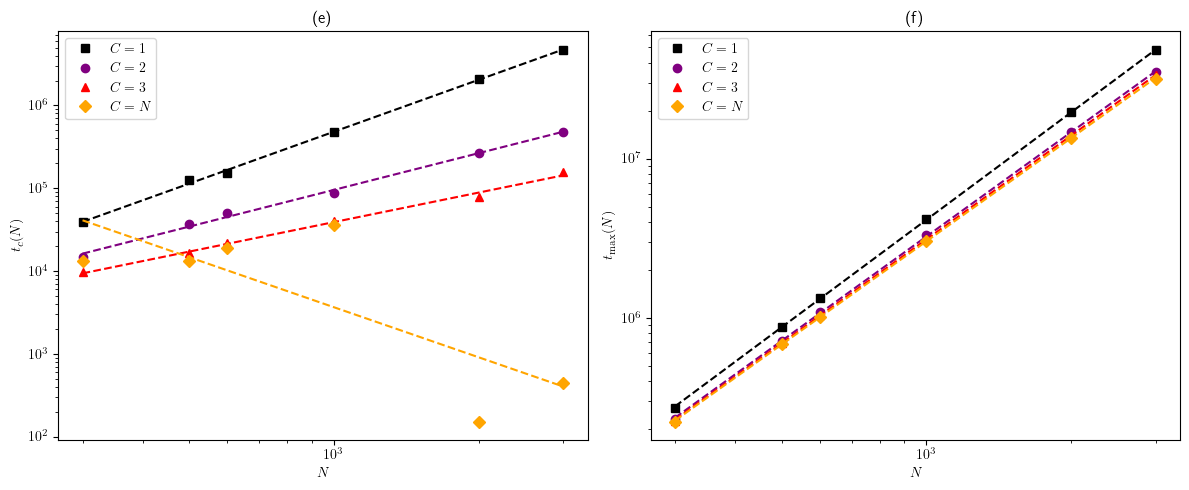


ESCALA DA RAZÃO t_c / t_max

$C=1$
t_c/t_max ~ N^-0.160 (R² = 0.817)
N=  300 | tc/tmax=1.427375e-01
N=  500 | tc/tmax=1.432808e-01
N=  600 | tc/tmax=1.138132e-01
N= 1000 | tc/tmax=1.134698e-01
N= 2000 | tc/tmax=1.069859e-01
N= 3000 | tc/tmax=9.843845e-02

$C=2$
t_c/t_max ~ N^-0.705 (R² = 0.982)
N=  300 | tc/tmax=6.421216e-02
N=  500 | tc/tmax=5.190218e-02
N=  600 | tc/tmax=4.642400e-02
N= 1000 | tc/tmax=2.613368e-02
N= 2000 | tc/tmax=1.818588e-02
N= 3000 | tc/tmax=1.376305e-02

$C=3$
t_c/t_max ~ N^-0.983 (R² = 0.991)
N=  300 | tc/tmax=4.313265e-02
N=  500 | tc/tmax=2.337327e-02
N=  600 | tc/tmax=2.082598e-02
N= 1000 | tc/tmax=1.292402e-02
N= 2000 | tc/tmax=5.594295e-03
N= 3000 | tc/tmax=4.708665e-03

$C=N$
t_c/t_max ~ N^-4.164 (R² = 0.868)
N=  300 | tc/tmax=6.011944e-02
N=  500 | tc/tmax=1.921253e-02
N=  600 | tc/tmax=1.855125e-02
N= 1000 | tc/tmax=1.187749e-02
N= 2000 | tc/tmax=1.122392e-05
N= 3000 | tc/tmax=1.412354e-05


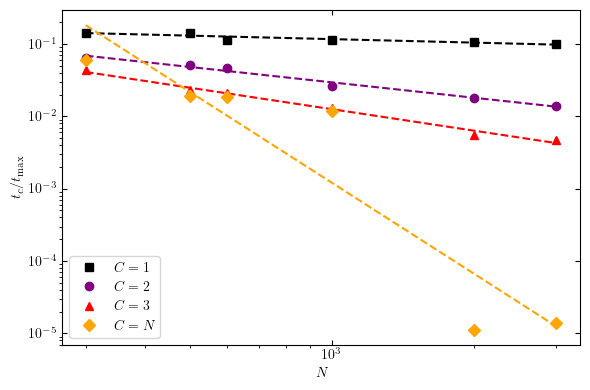


TESTE ASSINTÓTICO DE t_max

--------------------------------------------------------------------------------
$C=1$
--------------------------------------------------------------------------------

Ajuste direto: t_max ~ N^2.243 (R²=1.000)

Constantes a = t_max/N²:
N= 300 -> 3.030867
N= 500 -> 3.483544
N= 600 -> 3.722577
N=1000 -> 4.172322
N=2000 -> 4.891674
N=3000 -> 5.333473

Melhor expoente (min Var[log]): alpha = 2.2425


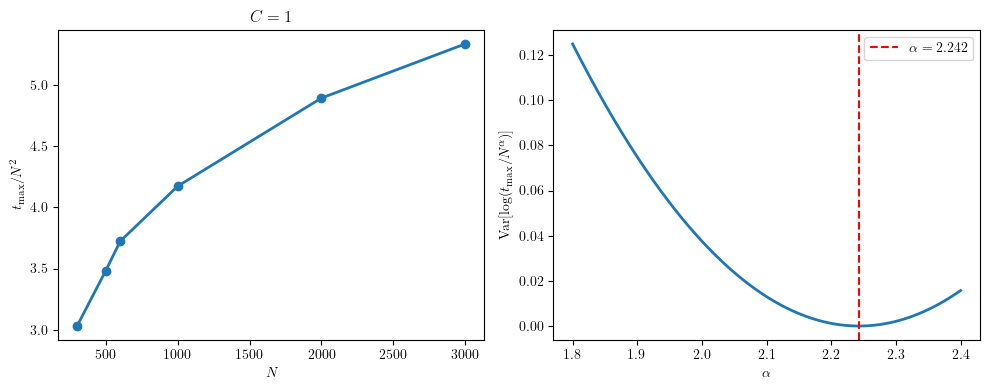


--------------------------------------------------------------------------------
$C=2$
--------------------------------------------------------------------------------

Ajuste direto: t_max ~ N^2.178 (R²=1.000)

Constantes a = t_max/N²:
N= 300 -> 2.564073
N= 500 -> 2.851647
N= 600 -> 3.010091
N=1000 -> 3.332021
N=2000 -> 3.665683
N=3000 -> 3.877354

Melhor expoente (min Var[log]): alpha = 2.1788


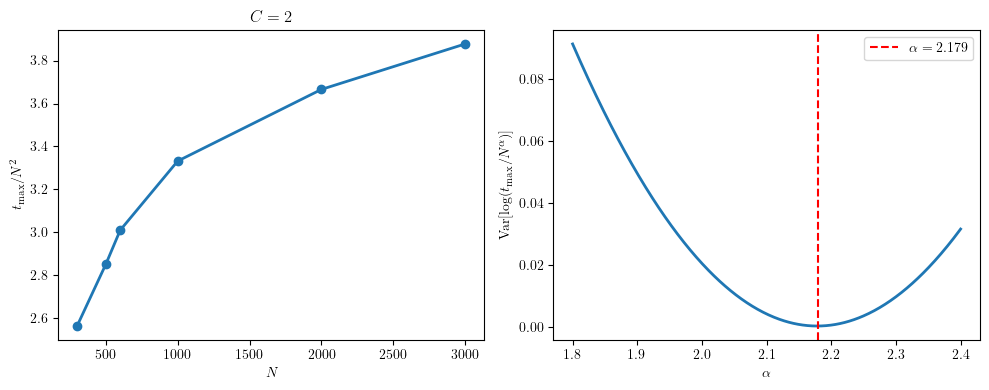


--------------------------------------------------------------------------------
$C=3$
--------------------------------------------------------------------------------

Ajuste direto: t_max ~ N^2.167 (R²=1.000)

Constantes a = t_max/N²:
N= 300 -> 2.492932
N= 500 -> 2.791834
N= 600 -> 2.895861
N=1000 -> 3.143208
N=2000 -> 3.472027
N=3000 -> 3.714158

Melhor expoente (min Var[log]): alpha = 2.1679


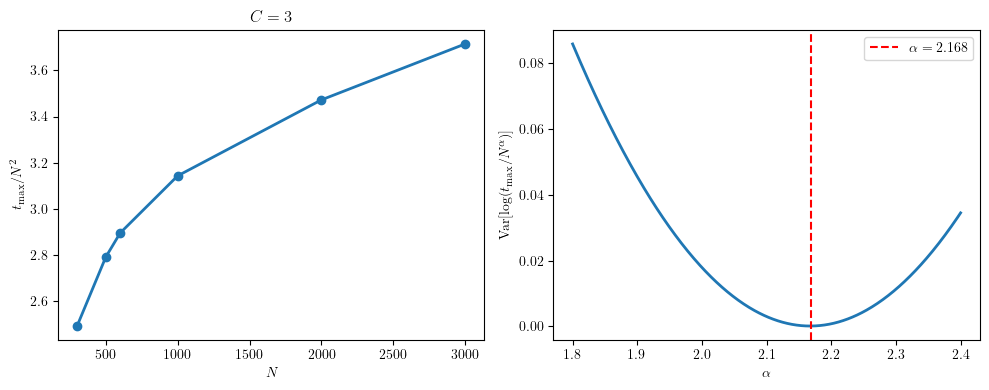


--------------------------------------------------------------------------------
$C=N$
--------------------------------------------------------------------------------

Ajuste direto: t_max ~ N^2.155 (R²=1.000)

Constantes a = t_max/N²:
N= 300 -> 2.477332
N= 500 -> 2.722409
N= 600 -> 2.815798
N=1000 -> 3.054945
N=2000 -> 3.392688
N=3000 -> 3.537972

Melhor expoente (min Var[log]): alpha = 2.1547


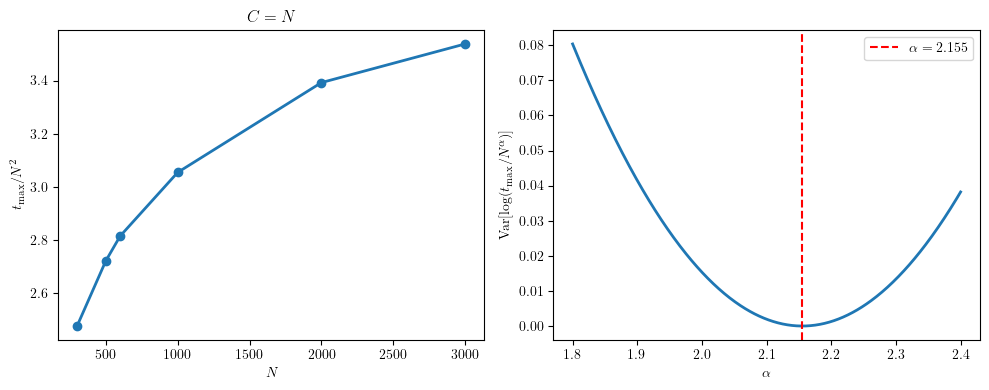

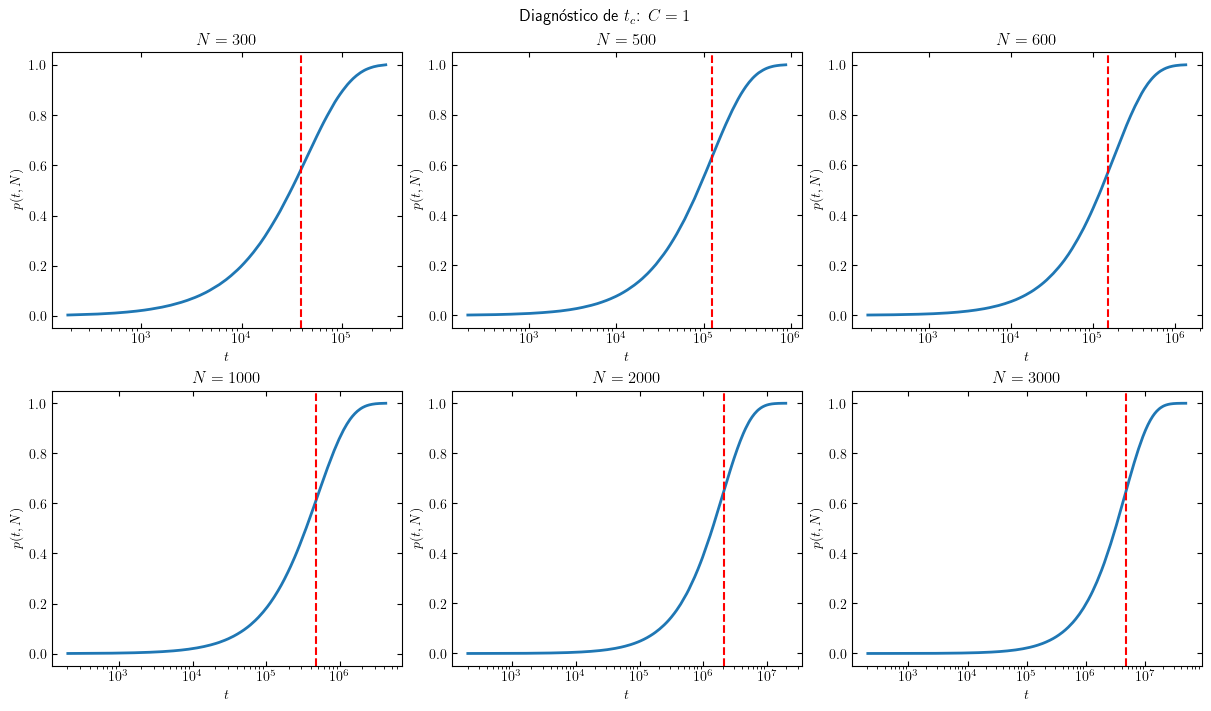

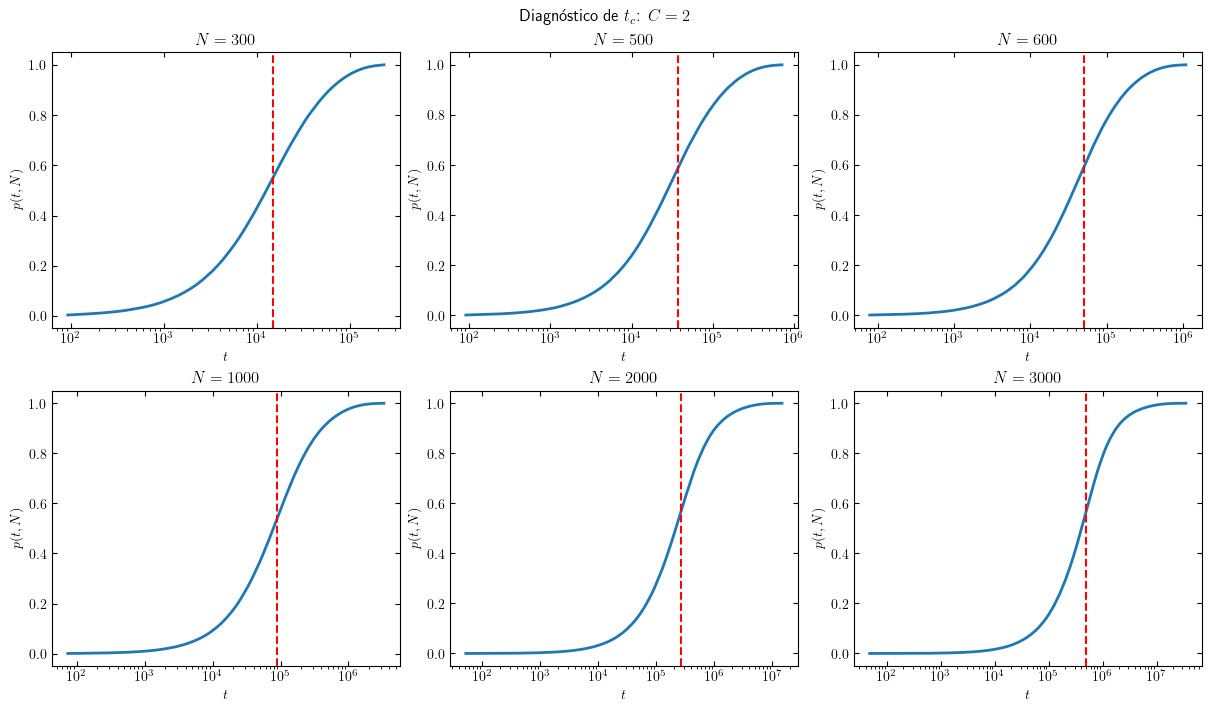

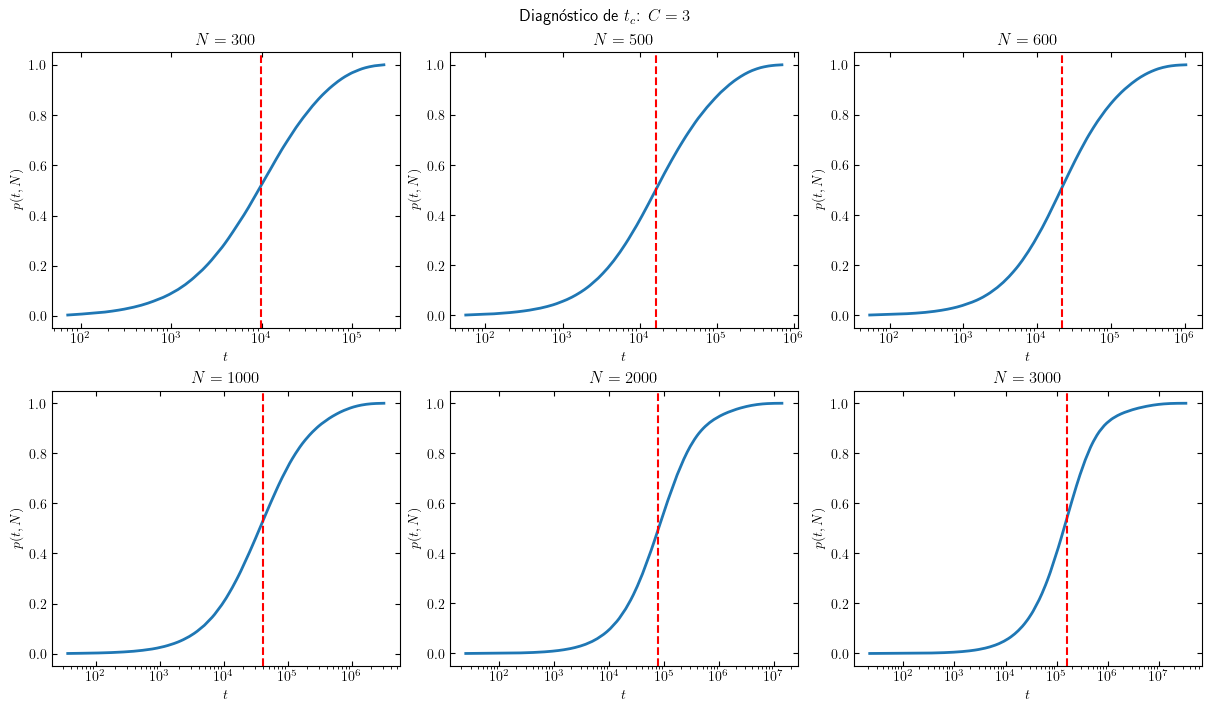

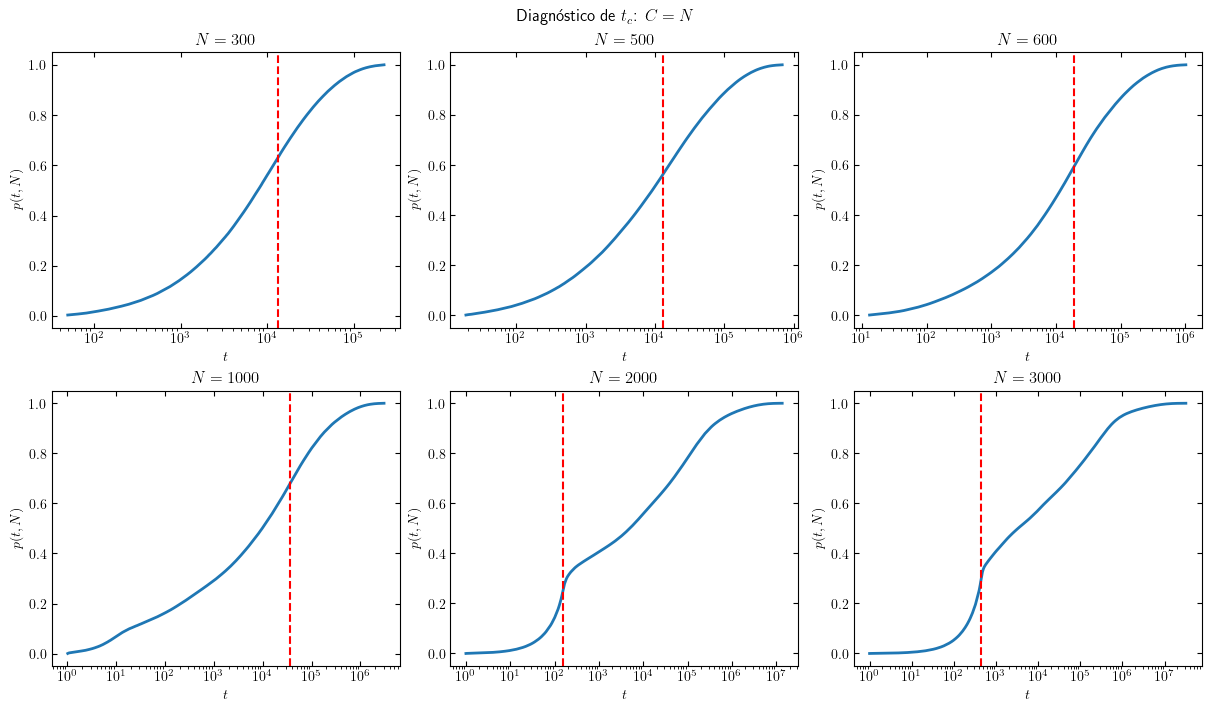


THETA POR COLAPSO
C=1: theta ≈ 2.096
C=2: theta ≈ 1.315
C=3: theta ≈ 1.210
C=N: theta ≈ 0.836


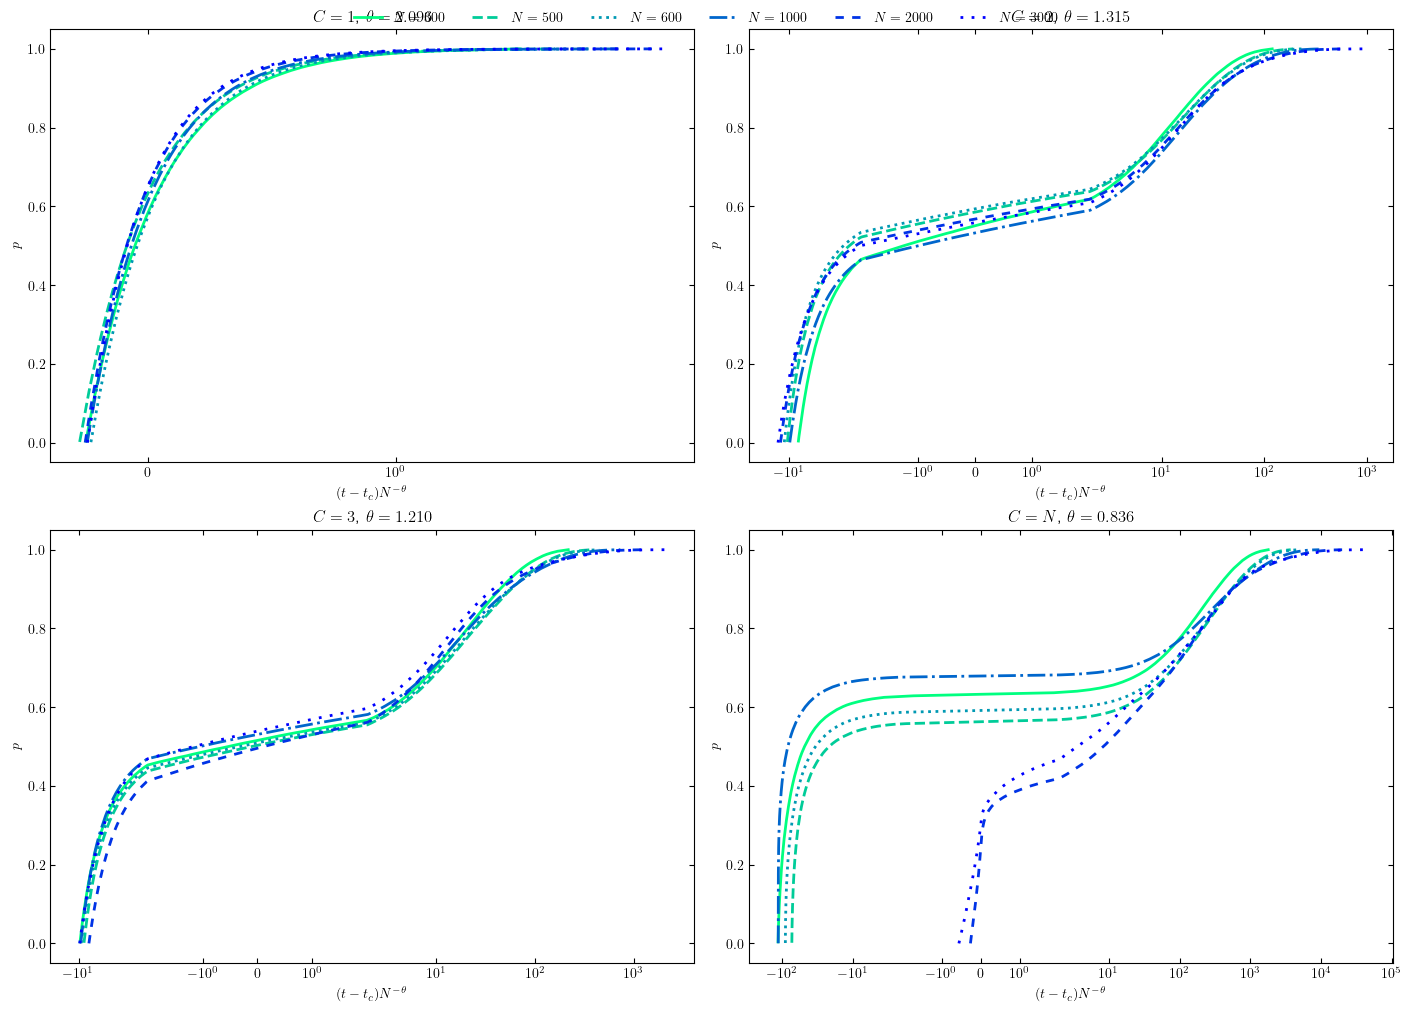

In [12]:
plot_final(mode="random")